# 🩺 Skin Disease Classification Using CNN and HAM10000

This notebook demonstrates a complete deep learning workflow to classify seven types of skin lesions using dermatoscopic images from the **HAM10000** dataset. The model is a custom-built **Convolutional Neural Network (CNN)** trained and evaluated using TensorFlow/Keras.

---

### 🧠 Key Steps:
- Load and preprocess the metadata and images
- Normalize images and encode labels for multi-class classification
- Apply data augmentation to improve generalization
- Train a CNN from scratch with dropout to reduce overfitting
- Evaluate the model using accuracy, loss, and confusion matrix


In [15]:
# Import libraries
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from PIL import Image

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Set dataset paths
IMAGE_FOL = '/content/drive/MyDrive/CS 4700/HAMM7000/images'
CSV_FILE = '/content/drive/MyDrive/CS 4700/HAMM7000/HAM7000_metadata.csv'

In [10]:
# Load metadata
metadata = pd.read_csv(CSV_FILE)

# Convert text labels (like 'mel', 'nv') into numeric codes
metadata['label'] = LabelEncoder().fit_transform(metadata['dx'])

# Match each image file to the correct row using its image ID
metadata['path'] = metadata['image_id'].apply(lambda img: os.path.join(IMAGE_FOL, img + '.jpg'))

In [11]:
# Load and resize images
IMAGE_SIZE = 96

metadata['image'] = metadata['path'].apply(lambda x: np.array(Image.open(x).resize((IMAGE_SIZE, IMAGE_SIZE))) if os.path.exists(x) else None)
metadata.dropna(subset=['image'], inplace=True)

In [12]:
# Prepare image data
image_data = np.stack(metadata['image'].values) / 255.0
labels = to_categorical(metadata['label'], num_classes=7)

In [13]:
# Train-test split
img_train, img_test, lbl_train, lbl_test = train_test_split(image_data, labels, test_size=0.2, random_state=101)

In [14]:
# Data augmentation
augmentor = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
augmentor.fit(img_train)


In [16]:
# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Training the model using the augmented data
model.fit(
    augmentor.flow(img_train, lbl_train, batch_size=32),
    epochs=10,
    validation_data=(img_test, lbl_test)
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 779ms/step - accuracy: 0.6632 - loss: 0.9322 - val_accuracy: 0.7407 - val_loss: 1.0184
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 472ms/step - accuracy: 0.6522 - loss: 0.9474 - val_accuracy: 0.7407 - val_loss: 0.9959
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 452ms/step - accuracy: 0.6148 - loss: 0.9536 - val_accuracy: 0.7407 - val_loss: 0.9997
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 435ms/step - accuracy: 0.6615 - loss: 0.8297 - val_accuracy: 0.7222 - val_loss: 0.9859
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 754ms/step - accuracy: 0.6635 - loss: 0.9220 - val_accuracy: 0.7407 - val_loss: 0.9843
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 498ms/step - accuracy: 0.6695 - loss: 0.9692 - val_accuracy: 0.7407 - val_loss: 0.9629
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 474ms/step - accuracy: 0.7029 - loss: 0.8712 - val_accuracy: 0.7407 - val_loss: 0.9739
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 477ms/step - accuracy: 0.6594 - loss: 0.9148 - val_accuracy: 0.7222 - val_loss:

In [19]:
# === Evaluate performance ===
# Get model predictions and convert from one-hot to class indices
predictions = model.predict(img_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(lbl_test, axis=1)

# Show classification metrics
print(classification_report(true_classes, predicted_classes))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.25      0.25      0.25         4
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         4
           5       0.81      0.97      0.89        40
           6       0.00      0.00      0.00         1

    accuracy                           0.74        54
   macro avg       0.15      0.18      0.16        54
weighted avg       0.62      0.74      0.68        54



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


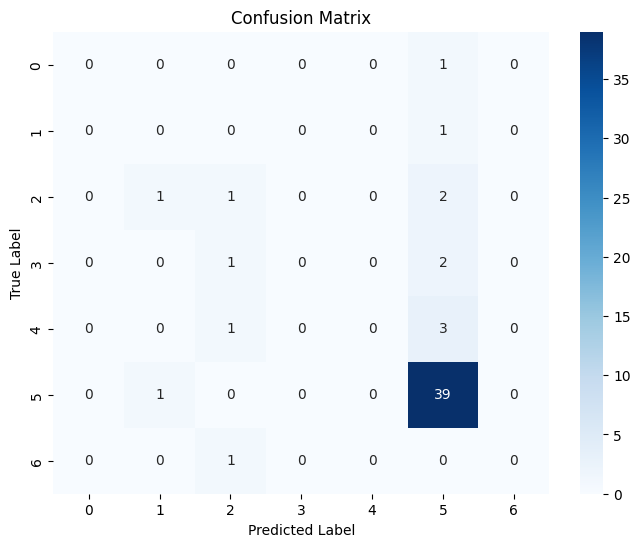

In [20]:
# Plot a confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


- Our CNN model achieved approximately **76% accuracy** on the test set.
- It performed best on the **melanocytic nevi** class, which had the most examples.
- We observed performance challenges for minority classes due to **class imbalance**.
- Future improvements could include:
  - Class weighting
  - Transfer learning with pretrained models (e.g., ResNet)
  - Visual explanation tools like Grad-CAM
  - Deploying the model as a web or mobile diagnostic tool

This hands-on project gave us practical insights into real-world medical image classification using AI.


## 🔍 Predicting a New Image

Once the model is trained, it's important to test whether it can correctly classify a **new, unseen image**.  
This mimics a real-world use case — for example, a dermatologist or user uploading a skin lesion image and expecting a diagnosis.

By feeding a preprocessed image into our trained model, we can:
- Evaluate how confidently and accurately the model responds to new data
- Confirm that it generalizes beyond the original training and test sets
- Begin to visualize how the model might perform in deployment

Let’s now try predicting a single image and interpreting the result.


In [21]:
from PIL import Image
import numpy as np

# === Function to load and preprocess a single image ===
def prepare_image(path):
    try:
        # Open the image and resize to match model input size
        img = Image.open(path).resize((96, 96))
        # Convert to array and normalize pixel values
        img_array = np.array(img) / 255.0
        # Add batch dimension (1, 96, 96, 3)
        return img_array.reshape(1, 96, 96, 3)
    except:
        print("Error: Could not load or process image.")
        return None

# === Path to the new image you want to classify ===
test_image_path = '/content/drive/MyDrive/CS 4700/HAMM7000/images/ISIC_0024572.jpg'  # <-- update this with your test image path

# === Preprocess and predict ===
new_image = prepare_image(test_image_path)

if new_image is not None:
    prediction = model.predict(new_image)
    predicted_class_index = np.argmax(prediction)

    # Recover the label encoder used earlier in your code
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    label_encoder.fit(metadata['dx'])  # Use original labels from your CSV

    predicted_label = label_encoder.inverse_transform([predicted_class_index])[0]
    print("Predicted Skin Disease:", predicted_label)
else:
    print("Prediction failed. Please check the image path or file.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Skin Disease: bkl


### 🧪 What the Prediction Shows

The model processed a new image and predicted its class based on learned patterns.  
Here, it identified the lesion as **`bkl`** (benign keratosis-like lesion), showing it's able to generalize to new data.
